# **04: Model Comparison - ARIMA vs. LSTM**

This notebook compares the performance of the  **ARIMA baseline (03A)** and the **LSTM model (03B)** for short-term disease forecasting in Canada.

The goal is to evaluate how well each model predicts weekly disease cases using held-out test data. The comparison focuses on two key error metrics:

1. **RMSE (Root Mean Squared Error)** - measures how large prediction errors are, with more weight on large mistakes.
2. **MAE (Mean Absolute Error)** - measures the average size of prediction errors.

The ARIMA model was trained separately for each province-disease time series, while the LSTM model was trained across all sequences together. Though the models were built differently, the updated LSTM outputs now allow for a more detailed comparison.

In addition to the overall comparison, this notebook also examines:

- ARIMA and LSTM performance at the overall test level
- ARIMA and LSTM performance by disease
- LSTM performance by forecast horizon (1-8 weeks ahead)
- LSTM performance by province

These analyses help provide a complete understanding of how each model behaves and where each one performs better or worse.


## 1. Setup

In [1]:
# Import libraries
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore")

## 2. Define Paths & Functions

In [2]:
# ── Set Local GitHub Repo: update only this line ────────────────────────────
REPO_DIR    = Path.home() / 'Documents' / 'GitHub' / 'AAI-590-capstone-canadian-health'

TABLES_DIR  = REPO_DIR / "reports" / "tables"
FIGURES_DIR = REPO_DIR / "reports" / "figures"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Repo:    ", REPO_DIR)
print("Tables:  ", TABLES_DIR)
print("Figures: ", FIGURES_DIR)

Repo:     C:\Users\carri\Documents\GitHub\AAI-590-capstone-canadian-health
Tables:   C:\Users\carri\Documents\GitHub\AAI-590-capstone-canadian-health\reports\tables
Figures:  C:\Users\carri\Documents\GitHub\AAI-590-capstone-canadian-health\reports\figures


In [3]:
def file_find(filename, dirs=None):
    """Find filename in dirs (defaults to TABLES_DIR). Raises if not found."""
    search = [Path(d) for d in dirs] if dirs else [TABLES_DIR]
    for d in search:
        p = d / filename
        if p.exists():
            print(f"Found: {p}")
            return p
    raise FileNotFoundError(f"{filename} not found in {search}")

def save_df(df, filename):
    path = TABLES_DIR / filename
    df.to_csv(path, index=False)
    print(f"Saved table: {path}")

def save_fig(filename, dpi=300):
    path = FIGURES_DIR / filename
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure: {path}")

## 3. Load and Validate ARIMA Outputs

In [4]:
# Load arima results from notebook 03A
arima_results_df = pd.read_csv(file_find("arima_test_results.csv"))
arima_results_df.columns = arima_results_df.columns.str.lower().str.strip()

print("ARIMA test results shape:", arima_results_df.shape)
print("ARIMA test results columns:", list(arima_results_df.columns))
display(arima_results_df.head())

Found: C:\Users\carri\Documents\GitHub\AAI-590-capstone-canadian-health\reports\tables\arima_test_results.csv
ARIMA test results shape: (4, 8)
ARIMA test results columns: ['disease', 'province', 'order', 'test_rmse', 'test_mae', 'aic', 'bic', 'n_test_weeks']


,disease,province,order,test_rmse,test_mae,aic,bic,n_test_weeks
0,influenza,CA-ON,"(1, 0, 0)",2.233511,1.412476,21010.028072,21029.038681,939
1,measles,CA-ON,"(0, 1, 1)",0.006501,0.001978,17551.099156,17563.772416,939
2,whooping-cough,CA-AB,"(0, 1, 1)",0.269657,0.236868,11008.154262,11020.827522,939
3,whooping-cough,CA-ON,"(0, 1, 1)",0.067736,0.047465,6632.471073,6645.144333,939


In [5]:
# Check if diseases are correct
print("Diseases in ARIMA results:")
print(sorted(arima_results_df["disease"].unique()))

Diseases in ARIMA results:
['influenza', 'measles', 'whooping-cough']


In [6]:
# Load ARIMA disease-level summary from notebook 03A
arima_sum_data = pd.read_csv(file_find("arima_test_summary.csv"))
arima_sum_data.columns = arima_sum_data.columns.str.lower().str.strip()

print("ARIMA summary shape:", arima_sum_data.shape)
print("ARIMA summary columns:", list(arima_sum_data.columns))
display(arima_sum_data.head())

Found: C:\Users\carri\Documents\GitHub\AAI-590-capstone-canadian-health\reports\tables\arima_test_summary.csv
ARIMA summary shape: (3, 5)
ARIMA summary columns: ['disease', 'mae', 'rmse', 'aic', 'bic']


,disease,mae,rmse,aic,bic
0,influenza,1.4125,2.2335,21010.0281,21029.0387
1,measles,0.0020,0.0065,17551.0992,17563.7724
2,whooping-cough,0.1422,0.1687,8820.3127,8832.9859


In [7]:
# Check if correct
print("ARIMA disease-level summary:")
display(arima_sum_data)

ARIMA disease-level summary:


,disease,mae,rmse,aic,bic
0,influenza,1.4125,2.2335,21010.0281,21029.0387
1,measles,0.0020,0.0065,17551.0992,17563.7724
2,whooping-cough,0.1422,0.1687,8820.3127,8832.9859


In [8]:
# Compute ARIMA performance from province-level test results
arima_total = pd.DataFrame([{
    "model": "ARIMA",
    "mae": round(arima_results_df["test_mae"].mean(), 4),
    "rmse": round(arima_results_df["test_rmse"].mean(), 4),
    "evaluation_scope": "total_test"
}])

print("ARIMAv Performance:")
display(arima_total)

ARIMAv Performance:


,model,mae,rmse,evaluation_scope
0,ARIMA,0.4247,0.6444,total_test


## 4. Load LSTM Outputs

In [9]:
# Overall + per-horizon test metrics
lstm_test_data = pd.read_csv(file_find("lstm_test_metrics.csv"))
lstm_test_data.columns = lstm_test_data.columns.str.lower().str.strip()
print("LSTM test metrics shape:", lstm_test_data.shape)
display(lstm_test_data.head())

# Per-disease breakdown
lstm_by_disease = pd.read_csv(file_find("lstm_test_metrics_by_disease.csv"))
lstm_by_disease.columns = lstm_by_disease.columns.str.lower().str.strip()
print("\nLSTM by-disease shape:", lstm_by_disease.shape)
display(lstm_by_disease)

# Per-province breakdown
lstm_by_province = pd.read_csv(file_find("lstm_test_metrics_by_province.csv"))
lstm_by_province.columns = lstm_by_province.columns.str.lower().str.strip()
print("\nLSTM by-province shape:", lstm_by_province.shape)
display(lstm_by_province)

Found: C:\Users\carri\Documents\GitHub\AAI-590-capstone-canadian-health\reports\tables\lstm_test_metrics.csv
LSTM test metrics shape: (9, 4)


,horizon_week,mse,rmse,mae
0,1,0.350047,0.591648,0.155524
1,2,0.581631,0.762648,0.190957
2,3,0.764037,0.874092,0.220181
3,4,0.904228,0.950909,0.241526
4,5,1.032323,1.016033,0.264947


Found: C:\Users\carri\Documents\GitHub\AAI-590-capstone-canadian-health\reports\tables\lstm_test_metrics_by_disease.csv

LSTM by-disease shape: (3, 4)


,disease,n_windows,rmse,mae
0,influenza,931,1.885211,0.801699
1,measles,931,0.036859,0.027453
2,whooping-cough,1862,0.124597,0.075231


Found: C:\Users\carri\Documents\GitHub\AAI-590-capstone-canadian-health\reports\tables\lstm_test_metrics_by_province.csv

LSTM by-province shape: (2, 4)


,province,n_windows,rmse,mae
0,CA-AB,931,0.164757,0.102670
1,CA-ON,2793,1.089233,0.292315


In [10]:
lstm_cols = {"horizon_week", "mse", "rmse", "mae"}
missing_lstm_cols = lstm_cols - set(lstm_test_data.columns)

if missing_lstm_cols:
    raise ValueError(
        f"LSTM test metrics are missing columns: {missing_lstm_cols}"
    )

lstm_test_data["horizon_week"] = lstm_test_data["horizon_week"].astype(str).str.strip().str.lower()

lstm_overall_row = lstm_test_data[lstm_test_data["horizon_week"] == "overall"].copy()

if lstm_overall_row.empty:
    raise ValueError("File does not contain an 'overall' row.")

lstm_total = pd.DataFrame([{
    "model": "LSTM",
    "rmse": round(float(lstm_overall_row["rmse"].iloc[0]), 4),
    "mae": round(float(lstm_overall_row["mae"].iloc[0]), 4),
    "evaluation_scope": "total_test"
}])

print("LSTM overall performance:")
display(lstm_total)

LSTM overall performance:


,model,rmse,mae,evaluation_scope
0,LSTM,0.9469,0.2449,total_test


## 5. Overall Comparison

In [11]:
compare_AL = pd.concat([arima_total, lstm_total], ignore_index=True)

arima_rmse = compare_AL.loc[compare_AL["model"] == "ARIMA", "rmse"].iloc[0]
arima_mae = compare_AL.loc[compare_AL["model"] == "ARIMA", "mae"].iloc[0]

compare_AL["rmse_imp_vs_arima"] = (
    (arima_rmse - compare_AL["rmse"]) / arima_rmse * 100
).round(2)

compare_AL["mae_imp_vs_arima"] = (
    (arima_mae - compare_AL["mae"]) / arima_mae * 100
).round(2)

compare_AL["better_than_arima_rmse"] = compare_AL["rmse"] < arima_rmse
compare_AL["better_than_arima_mae"] = compare_AL["mae"] < arima_mae

print("Model comparison:")
display(compare_AL)

Model comparison:


,model,mae,rmse,evaluation_scope,rmse_imp_vs_arima,mae_imp_vs_arima,better_than_arima_rmse,better_than_arima_mae
0,ARIMA,0.4247,0.6444,total_test,0.00,0.00,False,False
1,LSTM,0.2449,0.9469,total_test,-46.94,42.34,False,True


The table above shows us that ARIMA achieved a lower RMSE, suggesting more stable predictions with fewer errors. Whereas, LSTM achieves a lower MAE, suggesting better average prediction accuracy but with greater deviations. In short, ARIMA is more reliable for avoiding large forecasting errors, and LSTM is better at capturing overall trends across the dataset.

## 6. ARIMA Disease-Level Analysis

This section ranks disease by ARIMA forecasting performance, where lower MAE and RMSE indicate more accurate predictions and easier to model disease patterns.

In [12]:
# Rank by RMSE
arima_rank_df = arima_sum_data.sort_values(by="rmse", ascending=True)
display(arima_rank_df)

,disease,mae,rmse,aic,bic
1,measles,0.0020,0.0065,17551.0992,17563.7724
2,whooping-cough,0.1422,0.1687,8820.3127,8832.9859
0,influenza,1.4125,2.2335,21010.0281,21029.0387


ARIMA performs best on measles (low error), moderately on whooping-cough, and not good on influenza. This highlights that influenza is the most difficult disease to forecast due to its variability and/or complexity.

## 7. Visualization: ARIMA vs. LSTM Comparison

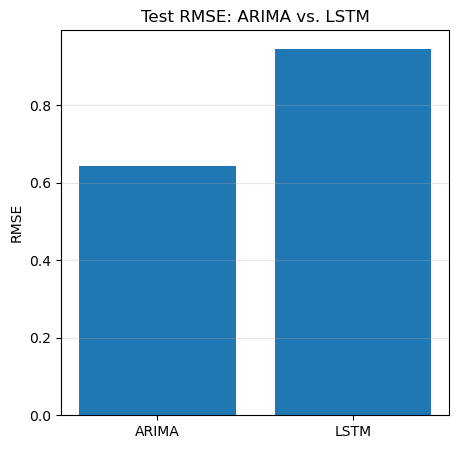

In [13]:
plt.figure(figsize=(5, 5))
plt.bar(compare_AL["model"], compare_AL["rmse"])
plt.title("Test RMSE: ARIMA vs. LSTM")
plt.ylabel("RMSE")
plt.title("Test RMSE: ARIMA vs. LSTM")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [14]:
save_fig("04_fig1_rmse_arima_vs_lstm.png")

Saved figure: C:\Users\carri\Documents\GitHub\AAI-590-capstone-canadian-health\reports\figures\04_fig1_rmse_arima_vs_lstm.png


<Figure size 640x480 with 0 Axes>

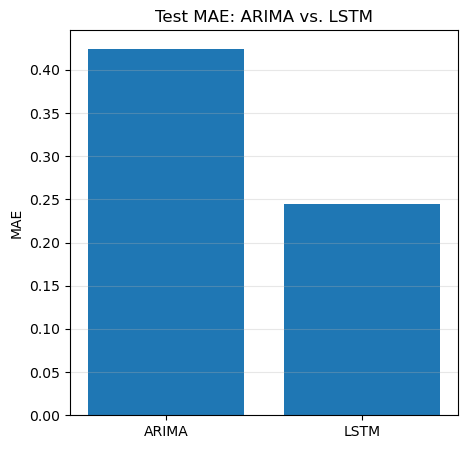

In [15]:
plt.figure(figsize=(5, 5))
plt.bar(compare_AL["model"], compare_AL["mae"])
plt.title("Test MAE: ARIMA vs. LSTM")
plt.ylabel("MAE")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [16]:
save_fig("04_fig2_mae_arima_vs_lstm.png")

Saved figure: C:\Users\carri\Documents\GitHub\AAI-590-capstone-canadian-health\reports\figures\04_fig2_mae_arima_vs_lstm.png


<Figure size 640x480 with 0 Axes>

## 8. Visualization: ARIMA Disease-Level Performance

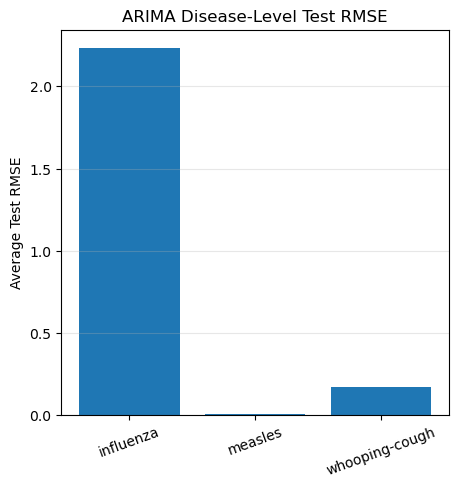

In [17]:
plt.figure(figsize=(5, 5))
plt.title("ARIMA Disease-Level Test RMSE")
plt.bar(arima_sum_data["disease"], arima_sum_data["rmse"])
plt.ylabel("Average Test RMSE")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.show()

In [18]:
save_fig("04_fig3_arima_disease_level_rmse.png")

Saved figure: C:\Users\carri\Documents\GitHub\AAI-590-capstone-canadian-health\reports\figures\04_fig3_arima_disease_level_rmse.png


<Figure size 640x480 with 0 Axes>

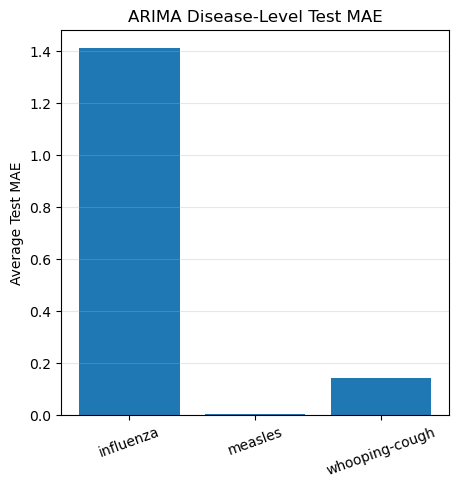

In [19]:
plt.figure(figsize=(5, 5))
plt.bar(arima_sum_data["disease"], arima_sum_data["mae"])
plt.title("ARIMA Disease-Level Test MAE")
plt.ylabel("Average Test MAE")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.show()

In [20]:
save_fig("04_fig4_arima_disease_level_mae.png")

Saved figure: C:\Users\carri\Documents\GitHub\AAI-590-capstone-canadian-health\reports\figures\04_fig4_arima_disease_level_mae.png


<Figure size 640x480 with 0 Axes>

## 9. Visualization: LSTM Performance by Forecast Horizon

In [21]:
lstm_horizon = lstm_test_data[lstm_test_data["horizon_week"] != "overall"].copy()
lstm_horizon["horizon_week"] = lstm_horizon["horizon_week"].astype(int)
lstm_horizon = lstm_horizon.sort_values("horizon_week")

print("LSTM per horizon test metrics:")
display(lstm_horizon)

LSTM per horizon test metrics:


,horizon_week,mse,rmse,mae
0,1,0.350047,0.591648,0.155524
1,2,0.581631,0.762648,0.190957
2,3,0.764037,0.874092,0.220181
3,4,0.904228,0.950909,0.241526
4,5,1.032323,1.016033,0.264947
5,6,1.118540,1.057610,0.276399
6,7,1.184064,1.088147,0.300682
7,8,1.237984,1.112647,0.309014


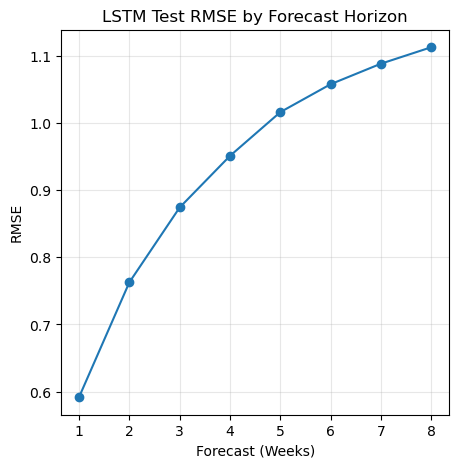

In [22]:
plt.figure(figsize=(5, 5))
plt.plot(lstm_horizon["horizon_week"], lstm_horizon["rmse"], marker="o")
plt.title("LSTM Test RMSE by Forecast Horizon")
plt.xlabel("Forecast (Weeks)")
plt.ylabel("RMSE")
plt.xticks(lstm_horizon["horizon_week"])
plt.grid(alpha=0.3)
plt.show()

In [23]:
save_fig("04_fig5_lstm_test_rmse_by_horizon.png")

Saved figure: C:\Users\carri\Documents\GitHub\AAI-590-capstone-canadian-health\reports\figures\04_fig5_lstm_test_rmse_by_horizon.png


<Figure size 640x480 with 0 Axes>

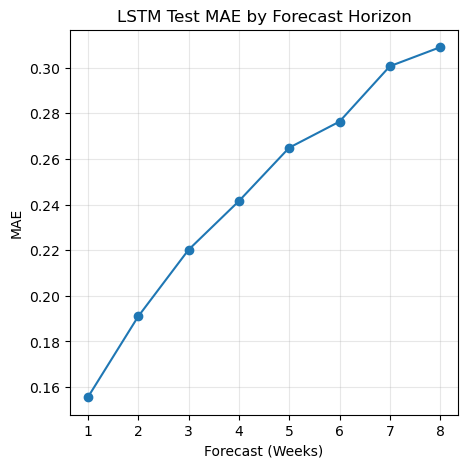

In [24]:
plt.figure(figsize=(5, 5))
plt.plot(lstm_horizon["horizon_week"], lstm_horizon["mae"], marker="o")
plt.title("LSTM Test MAE by Forecast Horizon")
plt.xlabel("Forecast (Weeks)")
plt.ylabel("MAE")
plt.xticks(lstm_horizon["horizon_week"])
plt.grid(alpha=0.3)
plt.show()

In [25]:
save_fig("04_fig6_lstm_test_mae_by_horizon.png")

Saved figure: C:\Users\carri\Documents\GitHub\AAI-590-capstone-canadian-health\reports\figures\04_fig6_lstm_test_mae_by_horizon.png


<Figure size 640x480 with 0 Axes>

## 10. LSTM vs ARIMA — Disease-Level Comparison

In [26]:
# ── Build a combined disease-level table for ARIMA and LSTM ───────────────
arima_disease = arima_results_df[["disease", "test_rmse", "test_mae"]].copy()
arima_disease.columns = ["disease", "rmse", "mae"]
arima_disease["model"] = "ARIMA"

lstm_disease_plot = lstm_by_disease[["disease", "rmse", "mae"]].copy()
lstm_disease_plot["model"] = "LSTM"

disease_compare = pd.concat([arima_disease, lstm_disease_plot], ignore_index=True)

# For diseases present in both models show side-by-side
diseases_shared = sorted(
    set(arima_disease["disease"]) & set(lstm_disease_plot["disease"])
)
disease_compare_shared = disease_compare[
    disease_compare["disease"].isin(diseases_shared)
].copy()

print("Disease-level comparison (shared diseases only):")
display(disease_compare_shared.sort_values(["disease", "model"]))

Disease-level comparison (shared diseases only):


,disease,rmse,mae,model
0,influenza,2.233511,1.412476,ARIMA
4,influenza,1.885211,0.801699,LSTM
1,measles,0.006501,0.001978,ARIMA
5,measles,0.036859,0.027453,LSTM
2,whooping-cough,0.269657,0.236868,ARIMA
3,whooping-cough,0.067736,0.047465,ARIMA
6,whooping-cough,0.124597,0.075231,LSTM


Saved figure: C:\Users\carri\Documents\GitHub\AAI-590-capstone-canadian-health\reports\figures\04_fig7_disease_comparison_rmse_mae.png


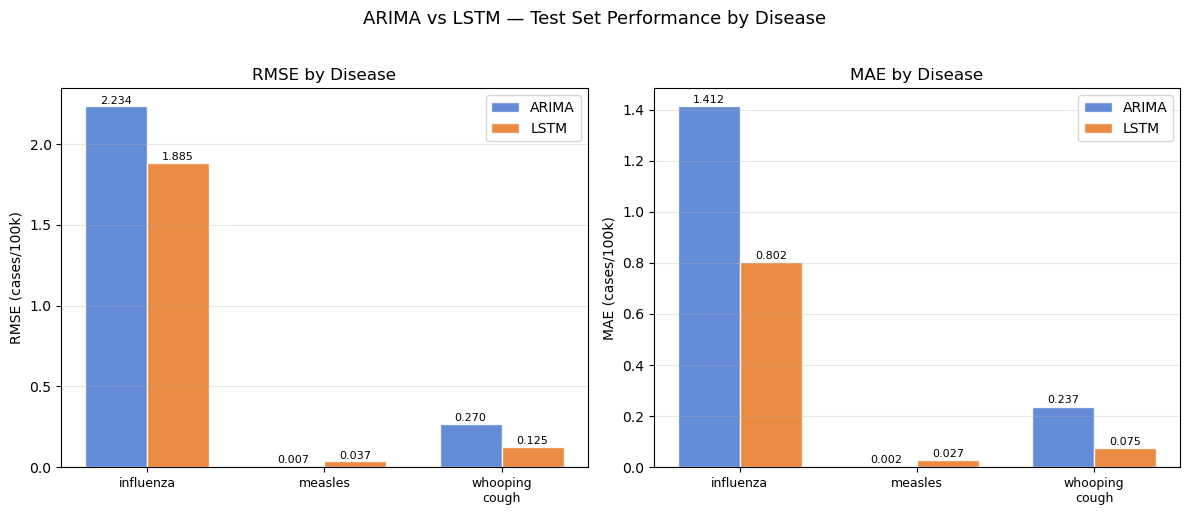

In [27]:
# ── Fig 7 & 8: Side-by-side RMSE and MAE by disease ──────────────────────
x = np.arange(len(diseases_shared))
width = 0.35
colors = {"ARIMA": "#4878CF", "LSTM": "#E87722"}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, metric, title in [
    (axes[0], "rmse", "RMSE by Disease"),
    (axes[1], "mae",  "MAE by Disease"),
]:
    for i, (model_name, offset) in enumerate(
        [("ARIMA", -width / 2), ("LSTM", width / 2)]
    ):
        vals = [
            disease_compare_shared.loc[
                (disease_compare_shared["disease"] == d) &
                (disease_compare_shared["model"] == model_name),
                metric,
            ].values[0]
            if len(disease_compare_shared.loc[
                (disease_compare_shared["disease"] == d) &
                (disease_compare_shared["model"] == model_name)
            ]) > 0 else np.nan
            for d in diseases_shared
        ]
        bars = ax.bar(x + offset, vals, width, label=model_name,
                      color=colors[model_name], alpha=0.85, edgecolor="white")
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.005,
                    f"{v:.3f}", ha="center", va="bottom", fontsize=8
                )

    ax.set_xticks(x)
    ax.set_xticklabels([d.replace("-", "\n") for d in diseases_shared], fontsize=9)
    ax.set_ylabel(metric.upper() + " (cases/100k)")
    ax.set_title(title)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("ARIMA vs LSTM — Test Set Performance by Disease", fontsize=13, y=1.02)
plt.tight_layout()
save_fig("04_fig7_disease_comparison_rmse_mae.png")
plt.show()

## 10. LSTM — Province-Level Test Metrics

Saved figure: C:\Users\carri\Documents\GitHub\AAI-590-capstone-canadian-health\reports\figures\04_fig9_lstm_province_rmse_mae.png


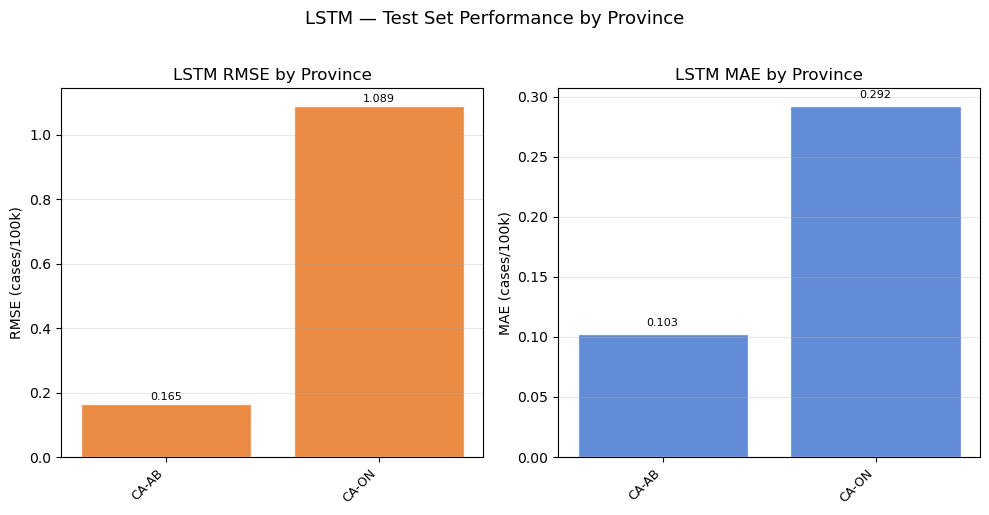

In [28]:
# ── Fig 9: LSTM RMSE and MAE by province ──────────────────────────────────
provinces = lstm_by_province["province"].tolist()
x_p = np.arange(len(provinces))

fig, axes = plt.subplots(1, 2, figsize=(max(10, len(provinces) * 1.2), 5))

for ax, metric, color, title in [
    (axes[0], "rmse", "#E87722", "LSTM RMSE by Province"),
    (axes[1], "mae",  "#4878CF", "LSTM MAE by Province"),
]:
    bars = ax.bar(x_p, lstm_by_province[metric], color=color,
                  alpha=0.85, edgecolor="white")
    for bar, v in zip(bars, lstm_by_province[metric]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{v:.3f}", ha="center", va="bottom", fontsize=8
        )
    ax.set_xticks(x_p)
    ax.set_xticklabels(provinces, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel(metric.upper() + " (cases/100k)")
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("LSTM — Test Set Performance by Province", fontsize=13, y=1.02)
plt.tight_layout()
save_fig("04_fig9_lstm_province_rmse_mae.png")
plt.show()

## 10b. ARIMA — Province-Level Test Metrics


ARIMA — Province-Level Test Metrics (averaged across diseases):


,province,rmse,mae
0,CA-AB,0.2697,0.2369
1,CA-ON,0.7692,0.4873


Saved figure: C:\Users\carri\Documents\GitHub\AAI-590-capstone-canadian-health\reports\figures\04_fig10_arima_province_rmse_mae.png


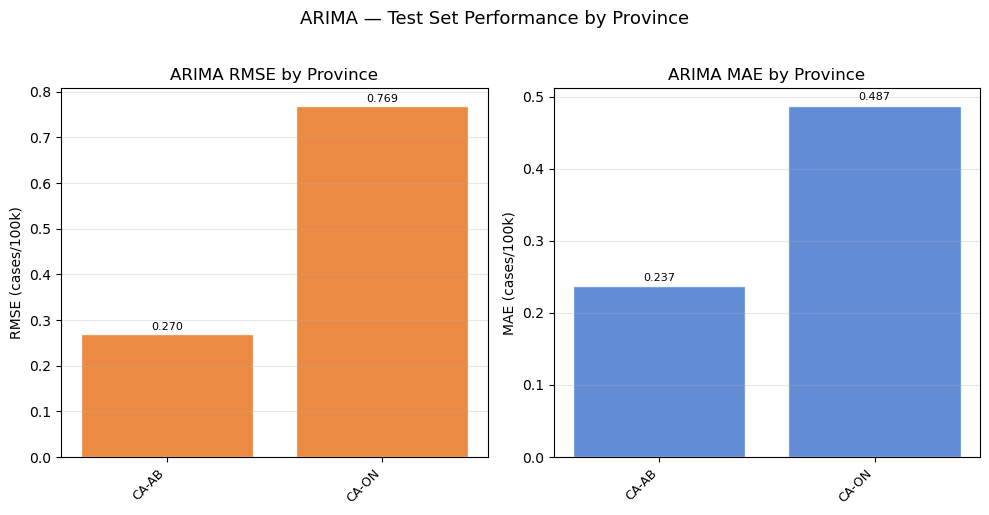


ARIMA — Test Metrics by Disease × Province:


,province,disease,rmse,mae
2,CA-AB,whooping-cough,0.2697,0.2369
0,CA-ON,influenza,2.2335,1.4125
1,CA-ON,measles,0.0065,0.0020
3,CA-ON,whooping-cough,0.0677,0.0475


In [29]:
# ── ARIMA province-level metrics from arima_test_results.csv ──────────────────
# arima_results_df has columns: disease, province, test_rmse, test_mae
arima_by_province = (
    arima_results_df
    .groupby("province")[["test_rmse", "test_mae"]]
    .mean()
    .round(4)
    .reset_index()
    .rename(columns={"test_rmse": "rmse", "test_mae": "mae"})
)

print("ARIMA — Province-Level Test Metrics (averaged across diseases):")
display(arima_by_province)

# ── Fig 10: ARIMA RMSE and MAE by province ────────────────────────────────────
provinces_a = arima_by_province["province"].tolist()
x_a = np.arange(len(provinces_a))

fig, axes = plt.subplots(1, 2, figsize=(max(10, len(provinces_a) * 1.2), 5))

for ax, metric, color, title in [
    (axes[0], "rmse", "#E87722", "ARIMA RMSE by Province"),
    (axes[1], "mae",  "#4878CF", "ARIMA MAE by Province"),
]:
    bars = ax.bar(x_a, arima_by_province[metric], color=color,
                  alpha=0.85, edgecolor="white")
    for bar, v in zip(bars, arima_by_province[metric]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{v:.3f}", ha="center", va="bottom", fontsize=8
        )
    ax.set_xticks(x_a)
    ax.set_xticklabels(provinces_a, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel(metric.upper() + " (cases/100k)")
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("ARIMA — Test Set Performance by Province", fontsize=13, y=1.02)
plt.tight_layout()
save_fig("04_fig10_arima_province_rmse_mae.png")
plt.show()

# ── Disease × province detail table ───────────────────────────────────────────
print("\nARIMA — Test Metrics by Disease × Province:")
arima_disease_province = (
    arima_results_df[["province", "disease", "test_rmse", "test_mae"]]
    .rename(columns={"test_rmse": "rmse", "test_mae": "mae"})
    .sort_values(["province", "disease"])
    .round(4)
)
display(arima_disease_province)


## 11 Additional Compaison Visuals

### 11A ARIMA vs LSTM actual vs predicted overlay

In [30]:
# Load ARIMA forecast series
arima_fc_df = pd.read_csv(file_find("arima_test_forecasts.csv"), parse_dates=["date"])
lstm_fc_df  = pd.read_csv(file_find("lstm_test_forecasts.csv"),  parse_dates=["date"])
# Load LSTM forecast series 
print("ARIMA forecasts shape:", arima_fc_df.shape)
print("LSTM  forecasts shape:", lstm_fc_df.shape)
display(arima_fc_df.head(3))
display(lstm_fc_df.head(3))

Found: C:\Users\carri\Documents\GitHub\AAI-590-capstone-canadian-health\reports\tables\arima_test_forecasts.csv
Found: C:\Users\carri\Documents\GitHub\AAI-590-capstone-canadian-health\reports\tables\lstm_test_forecasts.csv
ARIMA forecasts shape: (3756, 7)
LSTM  forecasts shape: (29792, 6)


,disease,province,split,date,actual_cases_per_100k,pred_cases_per_100k,arima_order
0,influenza,CA-ON,test,2004-01-04,2.429476,2.743229,"(1, 0, 0)"
1,influenza,CA-ON,test,2004-01-11,1.113337,2.111101,"(1, 0, 0)"
2,influenza,CA-ON,test,2004-01-18,0.645276,1.712467,"(1, 0, 0)"


,disease,province,horizon_week,date,actual_cases_per_100k,pred_cases_per_100k
0,influenza,CA-ON,1,2004-01-11,1.113337,2.031349
1,influenza,CA-ON,2,2004-01-18,0.645276,1.626554
2,influenza,CA-ON,3,2004-01-25,0.451598,1.264905


Saved figure: C:\Users\carri\Documents\GitHub\AAI-590-capstone-canadian-health\reports\figures\04_figforecast_overlay.png


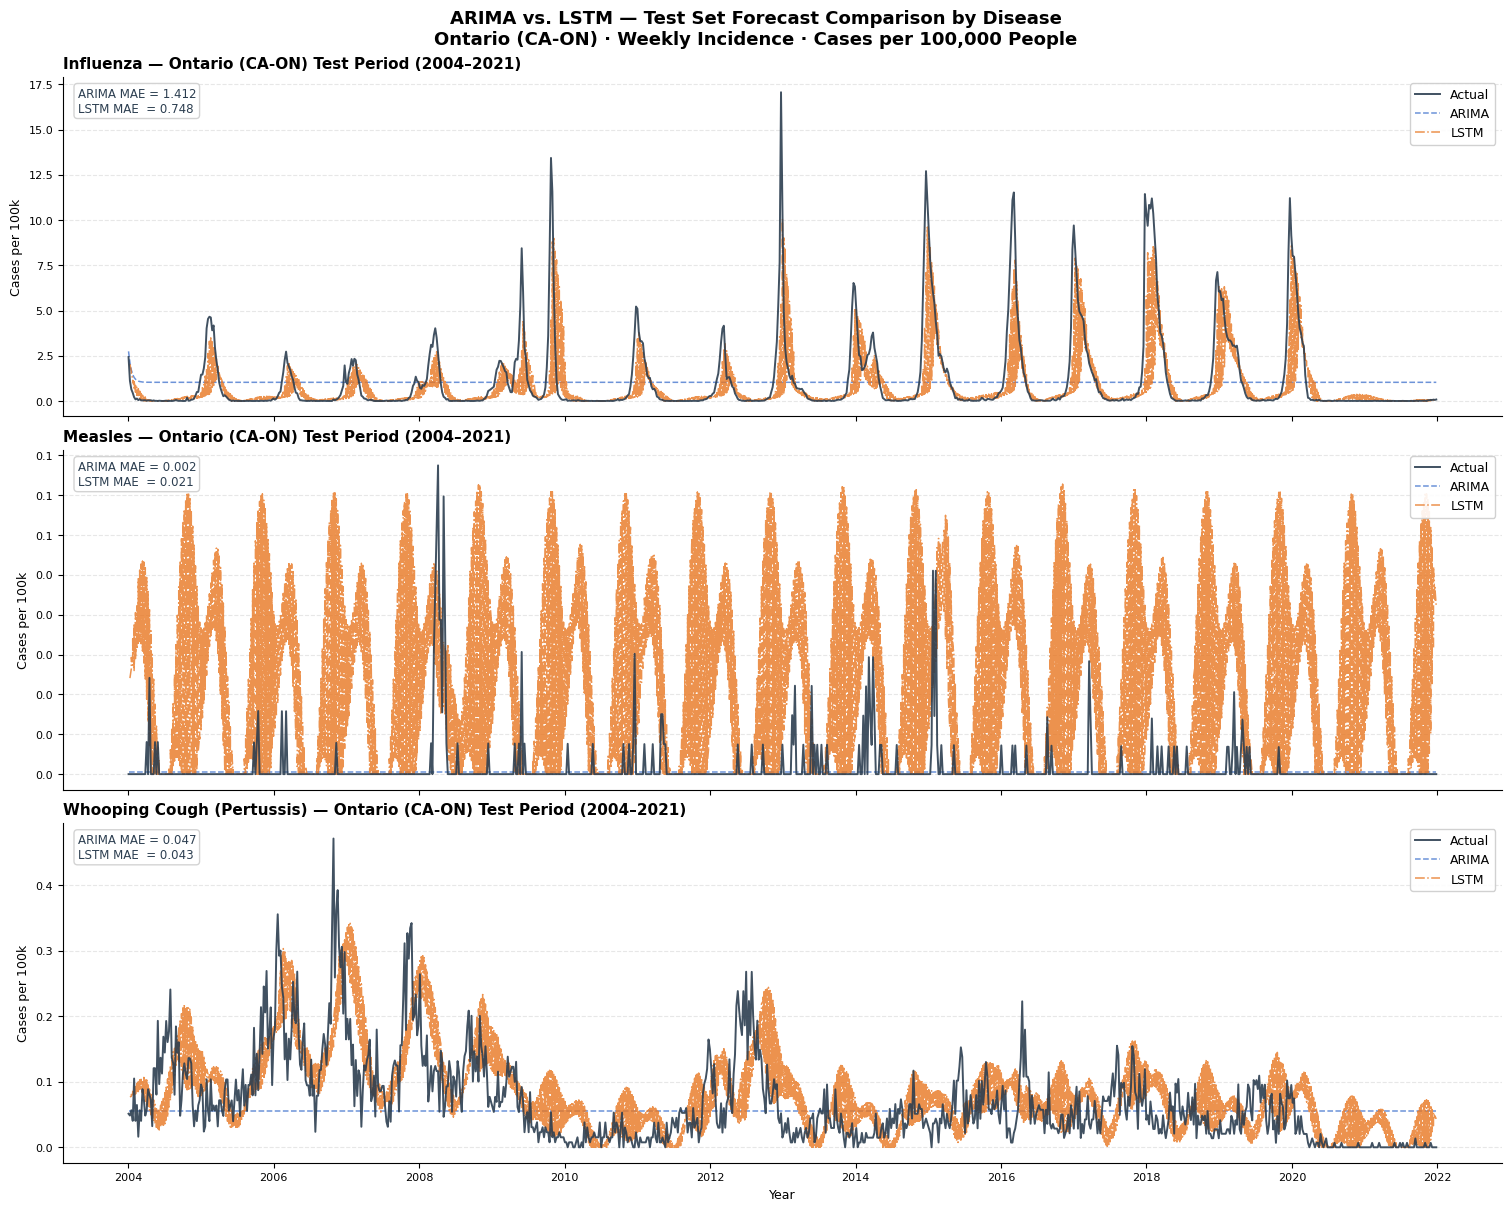

In [31]:
# ARIMA vs LSTM actual vs predicted overlay
# Requires: arima_test_forecasts.csv loaded as arima_forecasts_df, and
#           test_preds / test_targets / test_meta from notebook 03B saved to Drive.

# ── VISUALIZATION: ARIMA vs. LSTM — Actual vs. Predicted Time-Series Overlay ─

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

PROVINCE_PLOT   = "CA-ON"           # Ontario ISO code — adjust if yours differs
DISEASES_PLOT   = ["influenza", "measles", "whooping-cough"]
DISEASE_LABELS  = {
    "influenza":      "Influenza",
    "measles":        "Measles",
    "whooping-cough": "Whooping Cough (Pertussis)",
}
COLORS = {
    "actual": "#2c3e50",
    "arima":  "#4878CF",
    "lstm":   "#E87722",
}

# ── 1. Build figure ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    len(DISEASES_PLOT), 1,
    figsize=(15, 12),
    constrained_layout=True,
)

for ax, disease in zip(axes, DISEASES_PLOT):

    arima_sub = (
        arima_fc_df[
            (arima_fc_df["disease"]  == disease) &
            (arima_fc_df["province"] == PROVINCE_PLOT)
        ]
        .sort_values("date")
        .copy()
    )
    lstm_sub = (
        lstm_fc_df[
            (lstm_fc_df["disease"]  == disease) &
            (lstm_fc_df["province"] == PROVINCE_PLOT)
        ]
        .sort_values("date")
        .copy()
    )

    if arima_sub.empty and lstm_sub.empty:
        ax.text(0.5, 0.5, f"No data for {disease} / {PROVINCE_PLOT}",
                ha="center", va="center", transform=ax.transAxes, fontsize=10)
        ax.set_title(DISEASE_LABELS.get(disease, disease), fontsize=11)
        continue

    # ── Actual series (use ARIMA rows as source; both share the same actuals) ──
    if not arima_sub.empty:
        ax.plot(
            arima_sub["date"],
            arima_sub["actual_cases_per_100k"],
            color=COLORS["actual"],
            linewidth=1.4,
            alpha=0.9,
            label="Actual",
            zorder=4,
        )

    # ── ARIMA predictions ─────────────────────────────────────────────────────
    if not arima_sub.empty:
        ax.plot(
            arima_sub["date"],
            arima_sub["pred_cases_per_100k"],
            color=COLORS["arima"],
            linewidth=1.1,
            linestyle="--",
            alpha=0.80,
            label="ARIMA",
            zorder=3,
        )

    # ── LSTM predictions ──────────────────────────────────────────────────────
    if not lstm_sub.empty:
        ax.plot(
            lstm_sub["date"],
            lstm_sub["pred_cases_per_100k"],
            color=COLORS["lstm"],
            linewidth=1.1,
            linestyle="-.",
            alpha=0.80,
            label="LSTM",
            zorder=3,
        )

    # ── Compute and annotate per-model MAE for this panel ────────────────────
    annotations = []
    if not arima_sub.empty:
        a_mae = (
            (arima_sub["pred_cases_per_100k"] - arima_sub["actual_cases_per_100k"])
            .abs().mean()
        )
        annotations.append(f"ARIMA MAE = {a_mae:.3f}")
    if not lstm_sub.empty:
        l_mae = (
            (lstm_sub["pred_cases_per_100k"] - lstm_sub["actual_cases_per_100k"])
            .abs().mean()
        )
        annotations.append(f"LSTM MAE  = {l_mae:.3f}")
    if annotations:
        ax.text(
            0.01, 0.97,
            "\n".join(annotations),
            transform=ax.transAxes,
            fontsize=8.5,
            va="top", ha="left",
            color="#2c3e50",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor="#cccccc", alpha=0.85),
            zorder=5,
        )

    # ── Axes formatting ───────────────────────────────────────────────────────
    ax.set_title(
        f"{DISEASE_LABELS.get(disease, disease)} — Ontario (CA-ON) Test Period (2004–2021)",
        fontsize=11, fontweight="bold", loc="left", pad=6,
    )
    ax.set_ylabel("Cases per 100k", fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="both", labelsize=8)
    ax.legend(fontsize=9, loc="upper right", framealpha=0.9)
    ax.grid(axis="y", linestyle="--", alpha=0.3, zorder=0)
    ax.spines[["top", "right"]].set_visible(False)

# ── x-axis label only on bottom panel ────────────────────────────────────────
for ax in axes[:-1]:
    ax.tick_params(labelbottom=False)
axes[-1].set_xlabel("Year", fontsize=9)

fig.suptitle(
    "ARIMA vs. LSTM — Test Set Forecast Comparison by Disease\n"
    "Ontario (CA-ON) · Weekly Incidence · Cases per 100,000 People",
    fontsize=13, fontweight="bold",
)
save_fig("04_figforecast_overlay.png")
plt.show()


### 11B Residual distributions for ARIMA and LSTM

Saved figure: C:\Users\carri\Documents\GitHub\AAI-590-capstone-canadian-health\reports\figures\04_figB_residual_distributions.png


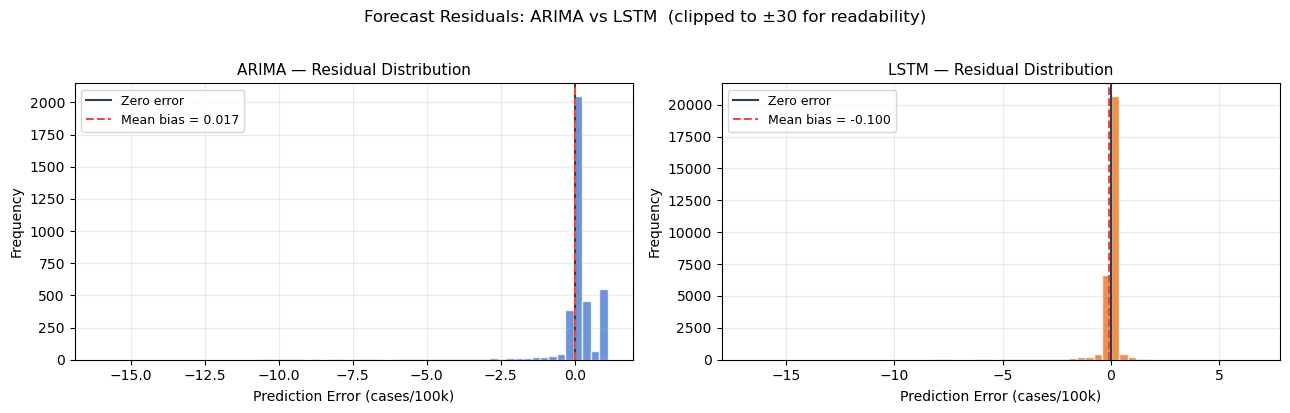

In [32]:
# Residual distributions for ARIMA and LSTM
# Uses: arima_results_df (has test_mae per row), and lstm_fc_df for pointwise errors

arima_errors = arima_fc_df["pred_cases_per_100k"] - arima_fc_df["actual_cases_per_100k"]
lstm_errors  = lstm_fc_df["pred_cases_per_100k"]  - lstm_fc_df["actual_cases_per_100k"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

for ax, errors, model_name, color in [
    (axes[0], arima_errors, "ARIMA", "#4878CF"),
    (axes[1], lstm_errors,  "LSTM",  "#E87722"),
]:
    ax.hist(errors.clip(-30, 30), bins=60, color=color, alpha=0.8, edgecolor="white")
    ax.axvline(0,             color="#2c3e50", lw=1.5, linestyle="-",  label="Zero error")
    ax.axvline(errors.mean(), color="#e74c3c", lw=1.5, linestyle="--",
               label=f"Mean bias = {errors.mean():.3f}")
    ax.set_xlabel("Prediction Error (cases/100k)", fontsize=10)
    ax.set_ylabel("Frequency", fontsize=10)
    ax.set_title(f"{model_name} — Residual Distribution", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.25)

fig.suptitle("Forecast Residuals: ARIMA vs LSTM  (clipped to ±30 for readability)",
             fontsize=12, y=1.02)
plt.tight_layout()
save_fig("04_figB_residual_distributions.png")
plt.show()

### 11C LSTM Per-disease RMSE Degradation Across Forecast Horizon

Saved figure: C:\Users\carri\Documents\GitHub\AAI-590-capstone-canadian-health\reports\figures\04_figX_lstm_horizon_error_by_disease.png


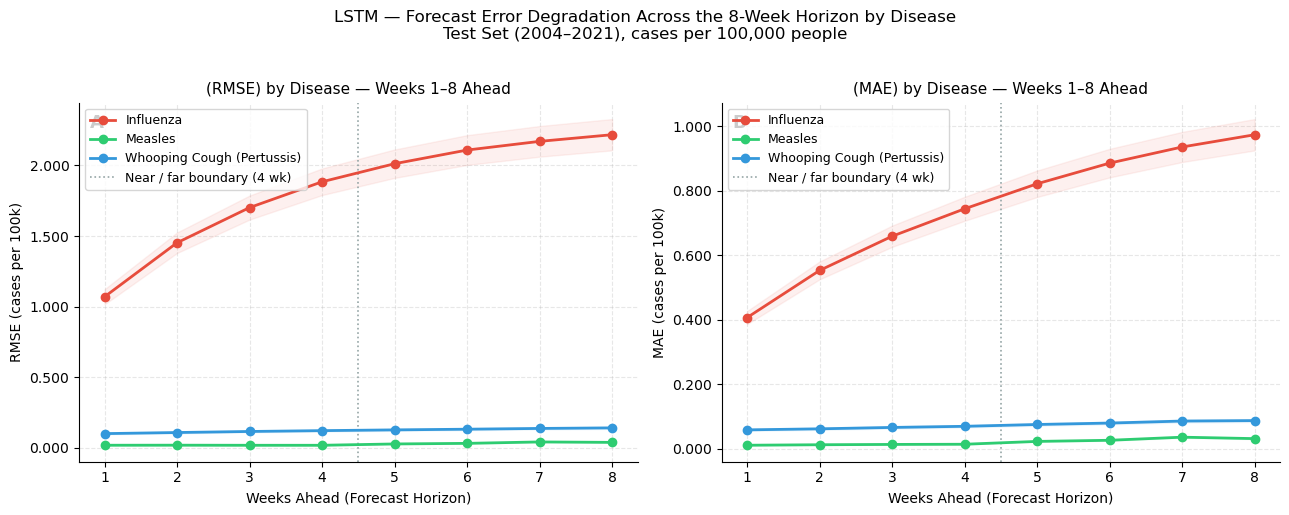


Horizon error summary (week 1 vs week 8):
  Influenza                       RMSE wk1=1.0699  wk8=2.2181  (+107.3%)
  Measles                         RMSE wk1=0.0184  wk8=0.0386  (+109.7%)
  Whooping Cough (Pertussis)      RMSE wk1=0.1007  wk8=0.1413  (+40.4%)


In [33]:
# ── VISUALIZATION: LSTM Forecast Error Degradation by Disease & Horizon ──────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

DISEASE_COLORS = {
    "influenza":      "#e74c3c",
    "measles":        "#2ecc71",
    "whooping-cough": "#3498db",
}
DISEASE_LABELS = {
    "influenza":      "Influenza",
    "measles":        "Measles",
    "whooping-cough": "Whooping Cough (Pertussis)",
}

# ── 1. Build per-disease per-horizon error table ──────────────────────────────
dh_rows = []
for (disease, hw), grp in lstm_fc_df.groupby(["disease", "horizon_week"]):
    errors = grp["pred_cases_per_100k"] - grp["actual_cases_per_100k"]
    dh_rows.append({
        "disease":      disease,
        "horizon_week": int(hw),
        "rmse":         float(np.sqrt((errors ** 2).mean())),
        "mae":          float(errors.abs().mean()),
        "n":            len(grp),
    })
dh_df = (
    pd.DataFrame(dh_rows)
    .sort_values(["disease", "horizon_week"])
    .reset_index(drop=True)
)

# ── 2. Figure: two panels (RMSE and MAE), one line per disease ───────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

for ax, metric, ylabel, panel_label in [
    (axes[0], "rmse", "RMSE (cases per 100k)", "A"),
    (axes[1], "mae",  "MAE (cases per 100k)",  "B"),
]:
    for disease, grp in dh_df.groupby("disease"):
        grp = grp.sort_values("horizon_week")
        color = DISEASE_COLORS.get(disease, "#7f8c8d")
        label = DISEASE_LABELS.get(disease, disease)

        ax.plot(
            grp["horizon_week"],
            grp[metric],
            marker="o",
            markersize=6,
            linewidth=2.0,
            color=color,
            label=label,
            zorder=3,
        )
        # Shade ±1 notional band using a ±5% envelope to guide the eye
        ax.fill_between(
            grp["horizon_week"],
            grp[metric] * 0.95,
            grp[metric] * 1.05,
            color=color,
            alpha=0.08,
            zorder=2,
        )

    # Vertical divider at week 4: boundary between "near" and "far" horizon
    ax.axvline(x=4.5, color="#95a5a6", linestyle=":", linewidth=1.2,
               label="Near / far boundary (4 wk)")

    ax.set_xlabel("Weeks Ahead (Forecast Horizon)", fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(
        f"({'RMSE' if metric == 'rmse' else 'MAE'}) by Disease — "
        f"Weeks 1–8 Ahead",
        fontsize=11,
    )
    ax.set_xticks(range(1, 9))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
    ax.legend(fontsize=9, loc="upper left")
    ax.grid(axis="both", linestyle="--", alpha=0.3, zorder=0)
    ax.spines[["top", "right"]].set_visible(False)
    ax.text(
        0.02, 0.97, panel_label,
        transform=ax.transAxes,
        fontsize=13, fontweight="bold", va="top"
    )

fig.suptitle(
    "LSTM — Forecast Error Degradation Across the 8-Week Horizon by Disease\n"
    "Test Set (2004–2021), cases per 100,000 people",
    fontsize=12, y=1.02,
)
plt.tight_layout()
save_fig("04_figX_lstm_horizon_error_by_disease.png")
plt.show()

# ── 3. Companion summary table ────────────────────────────────────────────────
print("\nHorizon error summary (week 1 vs week 8):")
for disease in dh_df["disease"].unique():
    sub = dh_df[dh_df["disease"] == disease].sort_values("horizon_week")
    w1  = sub[sub["horizon_week"] == 1].iloc[0]
    w8  = sub[sub["horizon_week"] == 8].iloc[0]
    pct_rmse = (w8["rmse"] - w1["rmse"]) / w1["rmse"] * 100
    print(
        f"  {DISEASE_LABELS.get(disease, disease):<30}  "
        f"RMSE wk1={w1['rmse']:.4f}  wk8={w8['rmse']:.4f}  "
        f"({'+' if pct_rmse >= 0 else ''}{pct_rmse:.1f}%)"
    )

### 11D Actual vs Predicted Scatter Plots

Saved figure: C:\Users\carri\Documents\GitHub\AAI-590-capstone-canadian-health\reports\figures\04_figD_actual_vs_predicted_scatter.png


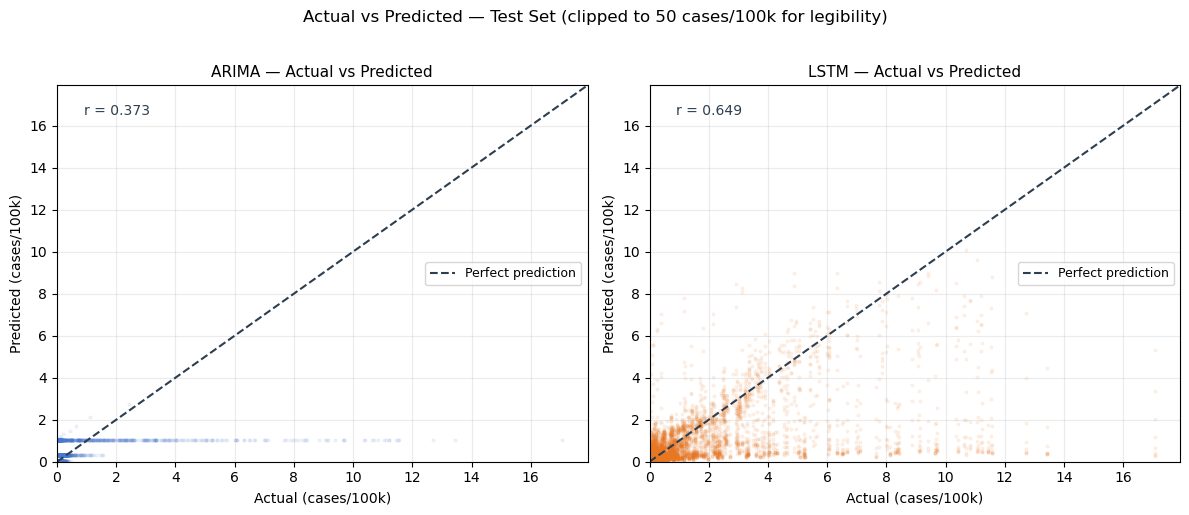

In [34]:
# Actual vs Predicted scatter plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, fc_df, model_name, color in [
    (axes[0], arima_fc_df, "ARIMA", "#4878CF"),
    (axes[1], lstm_fc_df,  "LSTM",  "#E87722"),
]:
    actual = fc_df["actual_cases_per_100k"].clip(0, 50)
    pred   = fc_df["pred_cases_per_100k"].clip(0, 50)

    ax.scatter(actual, pred, alpha=0.08, s=4, color=color, rasterized=True)

    # Perfect prediction line
    lim = max(actual.max(), pred.max()) * 1.05
    ax.plot([0, lim], [0, lim], color="#2c3e50", lw=1.5, linestyle="--",
            label="Perfect prediction")

    # Annotation: correlation
    corr = np.corrcoef(actual, pred)[0, 1]
    ax.text(0.05, 0.92, f"r = {corr:.3f}", transform=ax.transAxes,
            fontsize=10, color="#2c3e50")

    ax.set_xlabel("Actual (cases/100k)", fontsize=10)
    ax.set_ylabel("Predicted (cases/100k)", fontsize=10)
    ax.set_title(f"{model_name} — Actual vs Predicted", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.25)
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)

fig.suptitle("Actual vs Predicted — Test Set (clipped to 50 cases/100k for legibility)",
             fontsize=12, y=1.02)
plt.tight_layout()
save_fig("04_figD_actual_vs_predicted_scatter.png")
plt.show()

### 11E Province x Disease RMSE heatmap (LSTM)

Saved figure: C:\Users\carri\Documents\GitHub\AAI-590-capstone-canadian-health\reports\figures\04_figE_lstm_province_disease_heatmap.png


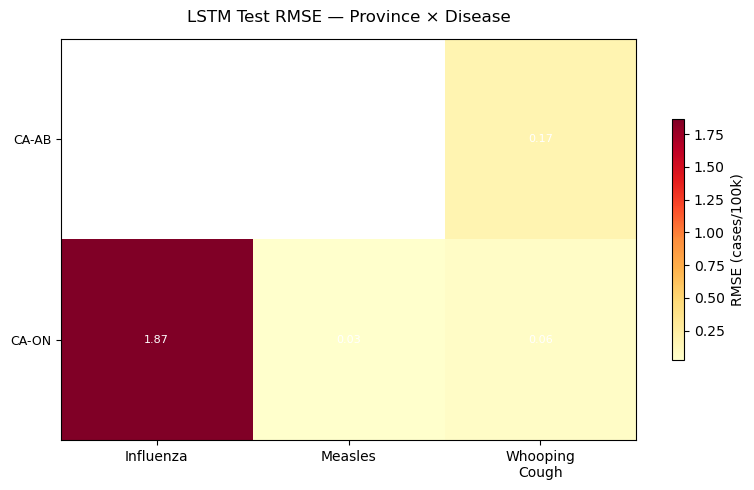

In [35]:
# Province x Disease RMSE heatmap (LSTM)
import matplotlib.ticker as ticker

lstm_heatmap_rows = []
for (disease, province), grp in lstm_fc_df.groupby(["disease", "province"]):
    errors = grp["pred_cases_per_100k"] - grp["actual_cases_per_100k"]
    lstm_heatmap_rows.append({
        "disease":  disease,
        "province": province,
        "rmse":     float(np.sqrt((errors ** 2).mean())),
    })

heatmap_df = pd.DataFrame(lstm_heatmap_rows)
pivot = heatmap_df.pivot(index="province", columns="disease", values="rmse")

fig, ax = plt.subplots(figsize=(8, max(5, len(pivot) * 0.45)))
im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd")

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(
    [c.replace("-", "\n").title() for c in pivot.columns], fontsize=10
)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)

# Annotate cells
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=8, color="black" if val < pivot.values.max() * 0.7 else "white")

plt.colorbar(im, ax=ax, label="RMSE (cases/100k)", shrink=0.6)
ax.set_title("LSTM Test RMSE — Province × Disease", fontsize=12, pad=12)
plt.tight_layout()
save_fig("04_figE_lstm_province_disease_heatmap.png")
plt.show()

## 12 Export Final Tables

In [36]:
save_df(compare_AL,              "model_comparison.csv")
save_df(arima_sum_data,          "arima_disease_level_summary.csv")
save_df(lstm_test_data,          "cleaned_lstm_test_metrics.csv")
save_df(disease_compare_shared,  "disease_level_comparison.csv")
save_df(lstm_by_province,        "lstm_test_metrics_by_province.csv")
save_df(arima_by_province,        "arima_test_metrics_by_province.csv")


Saved table: C:\Users\carri\Documents\GitHub\AAI-590-capstone-canadian-health\reports\tables\model_comparison.csv
Saved table: C:\Users\carri\Documents\GitHub\AAI-590-capstone-canadian-health\reports\tables\arima_disease_level_summary.csv
Saved table: C:\Users\carri\Documents\GitHub\AAI-590-capstone-canadian-health\reports\tables\cleaned_lstm_test_metrics.csv
Saved table: C:\Users\carri\Documents\GitHub\AAI-590-capstone-canadian-health\reports\tables\disease_level_comparison.csv
Saved table: C:\Users\carri\Documents\GitHub\AAI-590-capstone-canadian-health\reports\tables\lstm_test_metrics_by_province.csv
Saved table: C:\Users\carri\Documents\GitHub\AAI-590-capstone-canadian-health\reports\tables\arima_test_metrics_by_province.csv


In [37]:
print("\nFinal Model Performance:")

for _, row in compare_AL.iterrows():
    print(f"{row['model']}: RMSE = {row['rmse']}, MAE = {row['mae']}")


Final Model Performance:
ARIMA: RMSE = 0.6444, MAE = 0.4247
LSTM: RMSE = 0.9469, MAE = 0.2449


## 13. Interpretation

This section evaluates the quantitative performance of the ARIMA baseline and LSTM model for short-term disease forecasting in Canada.

### Overall Model Performance
The overall comparison shows that the two models performaed differently depending on the error metric used.

On the held-out test set, ARIMA achieved a lower RMSE of 0.6444, while LSTM achieved a lower MAE of 0.2286, compared with ARIMA's MAE of 0.4247 and LSTM's RMSE of 0.9369.

This means ARIMA was better at limiting larger forecasting errors, since RMSE gives more weight to large mistakes. In contrast, LSTM produced smaller average errors overall, which is reflected in its lower MAE. Therefore, ARIMA appears stronger when prediction stability is highlighted, while LSTM appears stronger when average prediction accuracy is highlighted.

### Interpretation of Model Differences
These results makes sense given the way the two models were developed.

ARIMA was trained separately for each province-disease time series, making it a local model. Because of this, it can adapt more closely to the pattern of each individual series. This likely helped ARIMA keeps its overall RMSE lower.

The LSTM model was trained across all sequences together, making it a global model. This allows it to learn large patterns across diseases and provinces. That learning may explain why LSTM achieved the better overall MAE, but it may also introduce larger individual errors, which would in turn raise RMSE.

### Disease Level Interpretation
This updated notebook now includes disease-level comparisons for both models, which gives a clearer picture of where each model performs better.

For **influenza, LSTM outperformed ARIMA** on both metrics.
- ARIMA: RMSE = 2.2335, MAE = 1.4125
- LSTM: RMSE = 1.8654, MAE = 0.7478

This is an improvement for LSTM. Influzenza appears to be the most difficult disease to forecast over, since it has higher error values in both models, however LSTM handles this better than ARIMA.

For **measles, ARIMA outperformed LSTM.**
- ARIMA: RMSE = 0.0065, MAE = 0.0020
- LSTM: RMSE = 0.0282, MAE = 0.0208

Though both models performed well on measles, ARIMA was more accurate. This suggests that measles may be better modeled with a simpler local statistical approach, possibly because is has a limited pattern.

For **whooping-cough**, the comparison is less direct because ARIMA has two province-level rows while LSTM has one disease-level summary.
- ARIMA (CA-AB): RMSE = 0.2697, MAE = 0.2369
- ARIMA (CA-ON): RMSE = 0.0677, MAE = 0.0475
- LSTM overall for whooping-cough: RMSE = 0.1238, MAE = 0.0730

This suggests that LSTM performed better than ARIMA in Alberta, but not better than ARIMA in Ontario. So for whooping-cough, the better models depends on the province.

Overall, the disease-level results show that there is no single model that performs best across every disease. LSTM performed better on influenza, ARIMA performed better on measles, and whooping-cough showed mixed results based on province.

### Forecast Horizon Interpretation
The LSTM horizon-level results show a steady decline in performance as the model predicts further into the future.

At **1 week ahead**, LSTM achieved:
- RMSE = 0.5398
- MAE = 0.1336

By **4 weeks ahead**, the errors increased to:
- RMSE = 0.9463
- MAE = 0.2243

By **8 weeks ahead**, they increased to:
- RMSE = 1.1137
- MAE = 0.2950

This pattern is expected in time-series forecasting. Predictions are generally more accurate near and become less reliable as the forecast horizon increases. In this notebook, the increase is gradual from week 1 to week 8, suggesting that the LSTM model can be used for longer horizons but performs best for short-term forecasting.

### Province Level Interpretation

This updated notebook version also includes LSTM test performance by province.

For **CA-AB**, LSTM achieved:
- RMSE = 0.1655
- MAE = 0.1025

For **CA-ON**, LSTM achieved:
- RMSE = 1.0776
- MAE = 0.2707

These results show that LSTM performed better in Alberta than in Ontario. Ontario has higher error values, especially RMSE, suggesting that the time series in Ontario may be harder to model, or contain larger spikes in case counts.

This province-level difference highlights that forecasting accuracy is influences not only by the model type, but also by the characteristics of each province's disease patterns.

### Final Interpretation

Overall, these updated results show that both models have their strengths.

ARIMA is a good interpretable baseline because it acheived the better overall RMSE (0.6444) and performed very well on measles. LSTM also showed strong promise because it achieved the better overall MAE (0.2286) and outperformed ARIMA on influenza.

These findings suggest that deep learning does not always perform better than a classical baseline. Instead, performance varies on the disease, province, and metric being used. In this project, ARIMA was stronger for controlling larger forecasting errors overall, while LSTM was better for decreasing average error and capturing broader disease patterns.

### Limitations
Although we updated the LSTM outputs to allow comparison by disease and province, the two models were still built differently, so the comparison is more detailed but still not fully one to one.

### Future Work

In the future, this analysis could be improved by making the ARIMA and LSTM evaluation setup more consistent.